
![logo](../../figs/holberton_logo.png)


# Stanford Dogs Classification 

## Goals of the Project

The main goal of this project is to build a Convolutional Neural Network (CNN) that can accurately classify images of dogs into their respective breeds using the Stanford Dogs dataset. 

The `Stanford Dogs` dataset contains images of 120 breeds of dogs from around the world. This dataset has been built using images and annotation from [ImageNet](https://www.image-net.org/) for the task of fine-grained image categorization. Contents of this dataset:

- Number of categories: `120`
- Number of images: `20,580`

## Key Steps

1. **Data Loading and Exploration**: Load the Stanford Dogs dataset using `TensorFlow Datasets` and explore its structure and contents.
2. **Data Preprocessing**: Prepare the data for training by resizing the images, normalizing pixel values, and applying data augmentation techniques to improve the model's generalization capability.
3. **Model Building**: Use a pretrained `MobileNetV2` model as the base and add custom layers on top of it to perform the classification task.
4. **Model Training**: Train the model on the preprocessed dataset, utilizing early stopping to avoid overfitting..
5. **Model Evaluation**: Evaluate the trained model on the test dataset to assess its performance.
6. **Visualization**: Visualize sample images from the dataset before and after preprocessing, and analyze the training and validation performance.


## 1. Data Loading and Exploration

We use `TensorFlow` and `TensorFlow Datasets` to load the Stanford Dogs dataset, splitting it into training and testing subsets. By specifying `shuffle_files=True` and `as_supervised=True`, we ensure the data is randomly ordered and returned in a convenient (`image, label`) format. 


Additionally, we retrieve metadata about the dataset with `with_info=True`, which provides useful information like the number of classes. 

We define `IMG_SIZE = (128, 128)` to standardize the dimensions of all images, ensuring consistency for feeding into our neural network model. This preparation is crucial for training and evaluating our dog breed classification model effectively.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

# Load the Stanford Dogs dataset
(ds_train, ds_test), ds_info = tfds.load('stanford_dogs', 
                                         split=['train', 'test'], 
                                         shuffle_files=True, 
                                         as_supervised=True, 
                                         with_info=True)

# Define the input image dimensions
IMG_SIZE = (224, 224)

In [2]:
import matplotlib.pyplot as plt

# Display dataset information
print("Dataset Information:")
print(ds_info)

# Check the structure of the dataset
print("\nTraining Dataset:")
for image, label in ds_train.take(1):
    print("Image shape:", image.shape)
    print("Label:", label.numpy())

print("\nTesting Dataset:")
for image, label in ds_test.take(1):
    print("Image shape:", image.shape)
    print("Label:", label.numpy())


Dataset Information:
tfds.core.DatasetInfo(
    name='stanford_dogs',
    full_name='stanford_dogs/0.2.0',
    description="""
    The Stanford Dogs dataset contains images of 120 breeds of dogs from around the
    world. This dataset has been built using images and annotation from ImageNet for
    the task of fine-grained image categorization. There are 20,580 images, out of
    which 12,000 are used for training and 8580 for testing. Class labels and
    bounding box annotations are provided for all the 12,000 images.
    """,
    homepage='http://vision.stanford.edu/aditya86/ImageNetDogs/main.html',
    data_dir='C:\\Users\\evisp\\tensorflow_datasets\\stanford_dogs\\0.2.0',
    file_format=tfrecord,
    download_size=778.12 MiB,
    dataset_size=744.72 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=120),
        'objects

## 2. Data Preprocessing

### 2.1 Standartize image sizes

Next, we standardize the input data for the neural network, ensuring consistent image dimensions and normalized pixel values across the dataset. 

To achieve that, we resize each image to a defined size (`IMG_SIZE` of `128x128` pixels) using `tf.image.resize`, and then normalizing the pixel values to a range between `0` and `1` by casting the image to `tf.float32` and dividing by `255.0`. 

We can inspect the range of sizes in the current images of the dataset to get a better understanding

In [3]:
# Define a function to check image sizes in the dataset
def check_image_sizes(dataset, num_samples=100):
    sizes = []
    for image, _ in dataset.take(num_samples):
        sizes.append(image.shape)
    return sizes

# Get sizes of images from the training dataset
train_sizes = check_image_sizes(ds_train)

# Get sizes of images from the testing dataset
test_sizes = check_image_sizes(ds_test)

# Display the unique sizes found in the sample
unique_train_sizes = set(train_sizes)
unique_test_sizes = set(test_sizes)

print("Unique image sizes in the training dataset sample:")
for size in unique_train_sizes:
    print(size)

print("\nUnique image sizes in the testing dataset sample:")
for size in unique_test_sizes:
    print(size)


Unique image sizes in the training dataset sample:
(437, 293, 3)
(321, 450, 3)
(505, 567, 3)
(454, 383, 3)
(500, 412, 3)
(400, 500, 3)
(500, 500, 3)
(195, 380, 3)
(350, 500, 3)
(309, 500, 3)
(299, 271, 3)
(500, 484, 3)
(500, 330, 3)
(367, 400, 3)
(525, 700, 3)
(500, 385, 3)
(322, 500, 3)
(180, 160, 3)
(374, 500, 3)
(273, 375, 3)
(364, 500, 3)
(200, 200, 3)
(334, 500, 3)
(360, 340, 3)
(500, 332, 3)
(500, 365, 3)
(500, 389, 3)
(380, 500, 3)
(370, 500, 3)
(310, 401, 3)
(600, 800, 3)
(267, 360, 3)
(634, 640, 3)
(333, 500, 3)
(547, 389, 3)
(747, 560, 3)
(480, 467, 3)
(417, 500, 3)
(500, 470, 3)
(500, 481, 3)
(500, 375, 3)
(469, 500, 3)
(1879, 1388, 3)
(207, 200, 3)
(481, 500, 3)
(500, 344, 3)
(375, 500, 3)
(500, 333, 3)
(500, 379, 3)
(461, 360, 3)
(180, 240, 3)

Unique image sizes in the testing dataset sample:
(300, 232, 3)
(190, 227, 3)
(336, 448, 3)
(206, 240, 3)
(325, 500, 3)
(347, 500, 3)
(500, 500, 3)
(175, 225, 3)
(500, 403, 3)
(478, 500, 3)
(372, 500, 3)
(500, 383, 3)
(316, 400, 3)


Our goal is to ensure uniformity in the input data by resizing all images to the same dimensions (`IMG_SIZE`) and normalizing their pixel values. 


By resizing the images, we ensure that they have **consistent dimensions**, which is essential for feeding them into a neural network. This consistency facilitates efficient batch processing during training. 

Normalizing the pixel values to a range between `0` and `1` helps stabilize the training process and prevents numerical instability, as it brings all pixel values to a similar scale. Additionally, **normalization can accelerate convergence during training by ensuring that the gradients are well-scaled*. 

While the `preprocess_image` function standardizes the input data, **ensuring uniform image dimensions and normalized pixel values, it may introduce some potential negative effects**. 
- Resizing the images to a fixed size (`IMG_SIZE`) can result in distortion or loss of information, especially if the aspect ratios of the original images vary significantly. 
- In some cases, resizing may lead to stretching or squashing of the images, potentially distorting their appearance and altering the features of interest. 

In [4]:
# Preprocess images to make them the same size
def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0  # Normalize pixel values
    return image, label

### 2.2 Visualize sample data

We provide a visual representation of a grid of images and their corresponding labels. 

First we take a batch of images and labels from the dataset, then plots the original images along with their labels in a grid layout. Afterward, we preprocesses the images and plot the preprocessed images alongside their labels. 


This way we visualize both the raw and processed versions of the dataset, allowing for an assessment of the preprocessing steps and their effects on the images. 

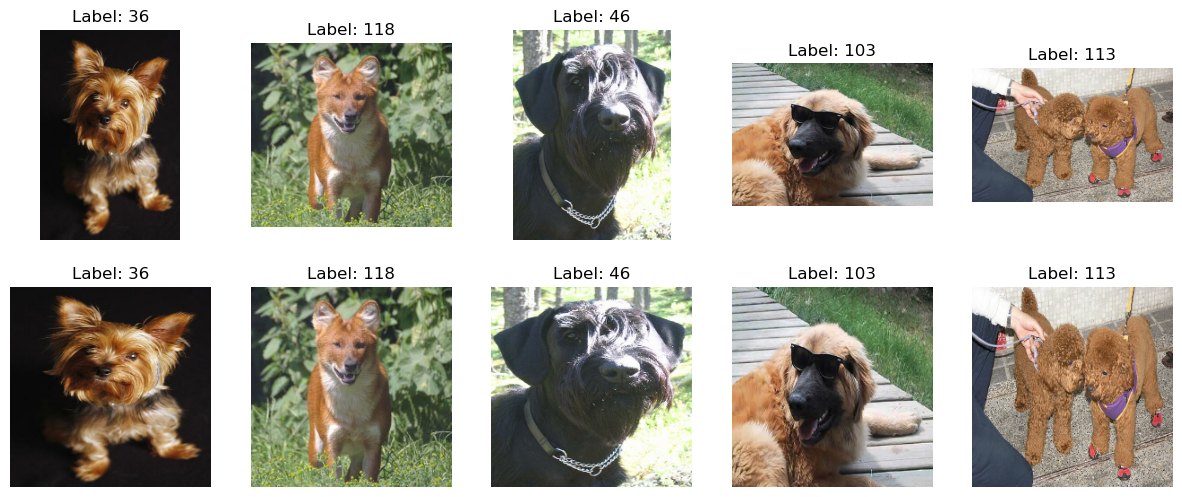

In [5]:
import matplotlib.pyplot as plt

# Define a function to visualize a grid of images
def visualize_samples(dataset, num_samples=5):
    # Take a batch of images and labels from the dataset
    sample_images = []
    sample_labels = []
    for image, label in dataset.take(num_samples):
        sample_images.append(image)
        sample_labels.append(label)
    
    # Plot the original images
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(sample_images[i].numpy())
        plt.title(f'Label: {sample_labels[i].numpy()}')
        plt.axis('off')
    
    # Preprocess the images
    preprocessed_images = []
    for image in sample_images:
        preprocessed_image, _ = preprocess_image(image, label)
        preprocessed_images.append(preprocessed_image)
    
    # Plot the preprocessed images
    for i in range(num_samples):
        plt.subplot(2, num_samples, num_samples + i + 1)
        plt.imshow(preprocessed_images[i].numpy())
        plt.title(f'Label: {sample_labels[i].numpy()}')
        plt.axis('off')
    
    plt.show()

# Visualize samples from the training dataset
visualize_samples(ds_train, num_samples=5)


### 2.3 Preprocessing and Dataset Configuration for Performance

In this step, we apply preprocessing to our training and testing datasets and configure them for optimal performance during model training. The `preprocess_image` function is applied to each image in the datasets, which includes resizing and normalization. Resizing ensures that all images are of the same dimensions, facilitating uniform processing by the neural network. Normalization scales the pixel values to a range between `0` and `1`, which helps stabilize and accelerate the training process.

By mapping the `preprocess_image` function to the datasets, we efficiently preprocess each image in parallel, leveraging the computational capabilities of modern hardware. Additionally, configuring the dataset for performance by setting `num_parallel_calls=tf.data.experimental.AUTOTUNE` allows `TensorFlow` to dynamically determine the optimal number of parallel calls based on available system resources. This ensures that our dataset is processed efficiently and ready for training, enhancing the overall speed and performance of our model.

In [6]:
# Apply preprocessing and configure the dataset for performance
ds_train = ds_train.map(preprocess_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
ds_test = ds_test.map(preprocess_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)


In this step, we organize our data for training by mixing up the examples and grouping them into batches. Shuffling the training data helps keep the model from picking up on any patterns related to the order of the examples. Batching lets us process multiple examples at once, which makes things faster since modern computers can handle lots of tasks simultaneously. By prefetching with `tf.data.experimental.AUTOTUNE`, `TensorFlow` figures out the best way to handle data storage, making sure everything runs smoothly and speeding up the training process overall.

In [7]:
# Shuffle and batch the datasets
BATCH_SIZE = 32
ds_train = ds_train.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

## 3. Transfer Learning with MobileNetV2

In this step, we leverage the power of transfer learning by utilizing the `MobileNetV2` model, a pre-trained convolutional neural network (CNN) architecture that has already learned rich features from a vast dataset (ImageNet). This approach saves time and computational resources, as we can repurpose the pre-trained MobileNetV2 model for our specific task of classifying images of dogs from the Stanford Dogs dataset.

### 3.1 Loading the Pre-trained MobileNetV2 Model

We import the `MobileNetV2` model from the `TensorFlow` Keras library and initialize it without the top classification layer (`include_top=False`) to use it solely as a feature extractor. By setting `weights='imagenet'`, we load the pre-trained weights trained on the `ImageNet` dataset, ensuring that the model has already learned to extract meaningful features from various images.

#### Freezing the Base Model
To prevent the pre-trained weights from being updated during training and preserve the learned features, we freeze the base `MobileNetV2` model by setting `base_model.trainable = False`.

### 3.2 Customizing the Classification Layers

Next, we customize the model by adding our own classification layers on top of the base `MobileNetV2` model. These custom layers allow the model to adapt to our specific classification task of identifying dog breeds. We incorporate several key techniques to enhance the model's performance and prevent overfitting:

- **Regularization**: We add `L2 `regularization to the dense layer to penalize large weights, promoting smoother and more generalized decision boundaries.

- **Batch Normalization**: To stabilize and speed up training, we include a BatchNormalization layer (BatchNormalization()) after the dense layer. Batch normalization normalizes the activations of each layer, reducing internal covariate shift and accelerating convergence.

- **Dropout**: Dropout is applied after batch normalization (Dropout(0.5)) to regularize the model further. It randomly deactivates some neurons during training, forcing the model to learn redundant representations and reducing the risk of overfitting.

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout


# Load pre-trained MobileNetV2 model without top classification layer
base_model = MobileNetV2(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), include_top=False, weights='imagenet')

# Freeze the base model
base_model.trainable = False


# Add custom classification layers on top of the base model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

# Define the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Add custom classification layers on top of the base model with regularization and batch normalization
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)  # Add L2 regularization
x = BatchNormalization()(x)  # Add BatchNormalization layer
x = Dropout(0.5)(x)  # Add dropout with a dropout rate of 0.5
output = Dense(ds_info.features['label'].num_classes, activation='softmax')(x)

# Create the transfer learning model with regularization and batch normalization
model = Model(inputs=base_model.input, outputs=output)
model.summary()




Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

## 4. Compile the model

Finally, we compile the model using the `Adam` optimizer, a popular choice for its adaptive learning rate capabilities. We specify the loss function as `sparse categorical crossentropy`, suitable for multi-class classification tasks, and track the accuracy metric to evaluate the model's performance during training.



In [9]:

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 4. Train the model

In this phase, we're executing the training process of our model. By utilizing the model.fit method, we iteratively expose our model to the training dataset over a specified number of epochs (in this case, 20). 


During each epoch, the model learns to recognize patterns and features in the images of dog breeds, adjusting its internal parameters (weights and biases) accordingly through optimization techniques like stochastic gradient descent. 


Concurrently, we validate the model's performance on the separate testing dataset, assessing its ability to generalize well beyond the training data. 


To prevent overfitting, a common pitfall in machine learning, we integrate the early_stopping callback, which halts the training process if the model's performance on the validation dataset fails to improve over a predefined number of epochs. 

In [10]:
history = model.fit(ds_train, epochs=20, validation_data=ds_test, callbacks=[early_stopping])

Epoch 1/20
375/375 [==============================] - 319s 836ms/step - loss: 4.0550 - accuracy: 0.4246 - val_loss: 2.2027 - val_accuracy: 0.6802
Epoch 2/20
375/375 [==============================] - 305s 814ms/step - loss: 2.0444 - accuracy: 0.6507 - val_loss: 1.5751 - val_accuracy: 0.7182
Epoch 3/20
375/375 [==============================] - 314s 836ms/step - loss: 1.6538 - accuracy: 0.6897 - val_loss: 1.4651 - val_accuracy: 0.7232
Epoch 4/20
375/375 [==============================] - 314s 837ms/step - loss: 1.5223 - accuracy: 0.6988 - val_loss: 1.4792 - val_accuracy: 0.7131
Epoch 5/20
375/375 [==============================] - 360s 959ms/step - loss: 1.4700 - accuracy: 0.7078 - val_loss: 1.3955 - val_accuracy: 0.7389
Epoch 6/20
375/375 [==============================] - 316s 843ms/step - loss: 1.4611 - accuracy: 0.7087 - val_loss: 1.4330 - val_accuracy: 0.7317
Epoch 7/20
375/375 [==============================] - 320s 854ms/step - loss: 1.4386 - accuracy: 0.7198 - val_loss: 1.4000 -

### 4.1 Visualize training performance

In this step, we visualize the training and validation performance of our model using line plots. The first plot displays the accuracy values over epochs, while the second plot shows the loss values.

In the results, we see that the model achieves a training accuracy of approximately `71.58%` and a validation accuracy of around `72.65%`. 

These results suggest that the model performs reasonably well, with similar performance on both the training and validation datasets, indicating no significant overfitting. 

However, there is room for improvement in terms of accuracy, as both training and validation accuracies could be higher. Further optimization efforts, such as fine-tuning the model architecture, adjusting hyperparameters, or increasing the dataset size, may lead to enhanced performance.

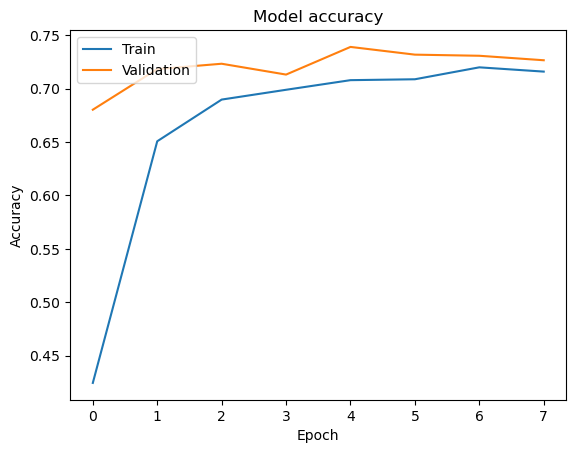

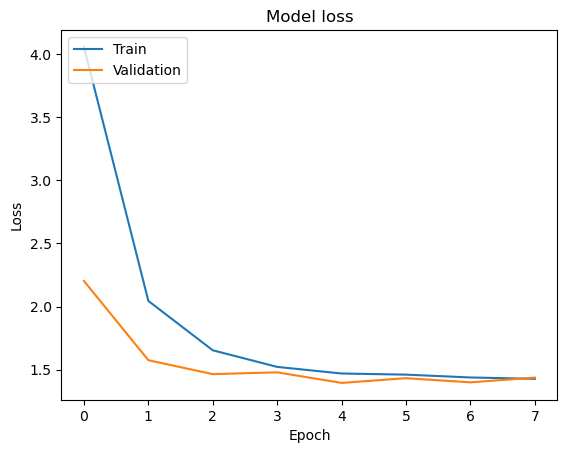

In [11]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


## 5. Test Model Performance 

In this step, we evaluate the trained model's performance on the testing dataset. The evaluate method computes the test loss and test accuracy, providing a quantitative measure of how well the model generalizes to unseen data. In this case, the test accuracy is approximately `73.89%`, indicating that the model performs reasonably well in classifying images from the testing dataset

In [13]:
# Evaluate the model on the testing dataset
test_loss, test_accuracy = model.evaluate(ds_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


269/269 [==============================] - 419s 2s/step - loss: 1.3955 - accuracy: 0.7389
Test Loss: 1.3954671621322632
Test Accuracy: 0.7389277219772339


## Happy Coding